# Lookup Classifier — Hard Labels

This notebook demonstrates building a lookup table with **hard labels** instead of soft labels.

For each `(name, cpg_sig)` key we:
1. Count raw reads per class.
2. Inspect the count distribution (intermediary state).
3. Take the `argmax` to assign the hard label.

We then verify that for DMR regions specific to cell type *c*, the hypomethylated pattern's argmax is indeed *c* (and not the background class).

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

# from syto.data.soft_labeling import extract_cpg_signature

## 1. Load training data and labels dict

In [2]:
DATA_DIR = Path(
    "../Data/training_data/SoftLabelsTrainingData_205files_pooled_Jaccard_hg38_mincpg_4_minlen_10_no_data_leak_d041"
)

df = pd.read_parquet(DATA_DIR / "train.parquet")
print(f"Loaded {len(df):,} reads across {df['name'].nunique()} regions")
df.head(3)

Loaded 2,910,114 reads across 843 regions


,chr,read_name,trimmed_start,trimmed_end,pattern,seq,name,region_start,region_end,original_label,...,dmr_ctype,read_length,dmr_label,cpg_sig,dmr_ctype_label,normalized_counts,soft_label,raw_reads_pooled,total_normalized_reads,num_signatures_pooled
0,chr1,2704570,1262135,1262211,1222222222121222122212222222222222212222222222...,CGTGAGCCACCGCGCCCGGCCGACCACTACTCACTCGGTGGTATAT...,chr1:1262136-1262432,1262135,1262432,0,...,Eryth-prog,76,0,"[[1262135, 1], [1262145, 1], [1262147, 1], [12...",15,"[5.116380688478983, 4.1837380897047955, 3.4786...","[0.035216894367804515, 0.028797361130587673, 0...",225,145,1
1,chr1,2704573,1262135,1262211,1222222222121222122212222222222222212222222222...,CGTGAGCCACCGCGCCCGGCCGACCACTACTCACTCGGTGGTATAT...,chr1:1262136-1262432,1262135,1262432,0,...,Eryth-prog,76,0,"[[1262135, 1], [1262145, 1], [1262147, 1], [12...",15,"[5.116380688478983, 4.1837380897047955, 3.4786...","[0.035216894367804515, 0.028797361130587673, 0...",225,145,1
2,chr1,2704575,1262135,1262211,1222222222121222122212222222222222212222222222...,CGTGAGCCACCGCGCCCGGCCGACCACTACTCACTCGGTGGTATAT...,chr1:1262136-1262432,1262135,1262432,0,...,Eryth-prog,76,0,"[[1262135, 1], [1262145, 1], [1262147, 1], [12...",15,"[5.116380688478983, 4.1837380897047955, 3.4786...","[0.035216894367804515, 0.028797361130587673, 0...",225,145,1


In [3]:
with open("../App/labels_dict.json") as f:
    labels_dict = json.load(f)

# int key -> label name
labels_dict = {int(k): v for k, v in labels_dict.items()}
labels_dict[len(labels_dict)] = "Background"
NUM_CLASSES = len(labels_dict)
print(f"{NUM_CLASSES} classes")
labels_dict

40 classes


{0: 'Adipocytes',
 1: 'Bladder-Ep',
 2: 'Blood-B',
 3: 'Blood-Granul',
 4: 'Blood-Mono+Macro',
 5: 'Blood-NK',
 6: 'Blood-T',
 7: 'Bone-Osteob',
 8: 'Breast-Basal-Ep',
 9: 'Breast-Luminal-Ep',
 10: 'Colon-Ep',
 11: 'Colon-Fibro',
 12: 'Dermal-Fibro',
 13: 'Endothel',
 14: 'Epid-Kerat',
 15: 'Eryth-prog',
 16: 'Fallopian-Ep',
 17: 'Gallbladder',
 18: 'Gastric-Ep',
 19: 'Head-Neck-Ep',
 20: 'Heart-Cardio',
 21: 'Heart-Fibro',
 22: 'Kidney-Ep',
 23: 'Liver-Hep',
 24: 'Lung-Ep-Alveo',
 25: 'Lung-Ep-Bron',
 26: 'Neuron',
 27: 'Oligodend',
 28: 'Ovary-Ep',
 29: 'Pancreas-Acinar',
 30: 'Pancreas-Alpha',
 31: 'Pancreas-Beta',
 32: 'Pancreas-Delta',
 33: 'Pancreas-Duct',
 34: 'Prostate-Ep',
 35: 'Skeletal-Musc',
 36: 'Small-Int-Ep',
 37: 'Smooth-Musc',
 38: 'Thyroid-Ep',
 39: 'Background'}

## 2. Ensure `cpg_sig` is a tuple

In [4]:
# The parquet already has cpg_sig but stored as list-of-lists; convert to tuple-of-tuples
df["cpg_sig"] = df["cpg_sig"].apply(
    lambda x: tuple(tuple(p) for p in x) if not isinstance(x, tuple) else x
)
df["cpg_sig"].iloc[0]

((np.int64(1262135), np.int64(1)),
 (np.int64(1262145), np.int64(1)),
 (np.int64(1262147), np.int64(1)),
 (np.int64(1262151), np.int64(1)),
 (np.int64(1262155), np.int64(1)),
 (np.int64(1262170), np.int64(1)))

## 3. Build raw count table per `(name, cpg_sig)` and normalize

This is the **intermediary state** before any argmax. Each row is a unique `(region, signature)` and the columns `0..39` hold the raw read counts per class.

We then apply the same **global sequencing-depth normalization** as `apply_normalized_knn_smoothing`: compute per-class weights as `median_count / class_count` and multiply the raw counts.

In [5]:
LABEL_COL = "label"

base_counts = df.groupby(["name", "cpg_sig", LABEL_COL]).size().unstack(fill_value=0)
base_counts = base_counts.reindex(columns=range(NUM_CLASSES), fill_value=0)
base_counts = base_counts.reset_index()

class_cols = list(range(NUM_CLASSES))
base_counts["total_reads"] = base_counts[class_cols].sum(axis=1)

print(f"{len(base_counts):,} unique (name, cpg_sig) keys")
print(f"\nRaw counts (before normalization):")
base_counts.head()

170,341 unique (name, cpg_sig) keys

Raw counts (before normalization):


label,name,cpg_sig,0,1,2,3,4,5,6,7,...,31,32,33,34,35,36,37,38,39,total_reads
0,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 0...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,4,70
1,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 0...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,6,6
2,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 1...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3,3
3,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 1...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,10,10
4,chr10:103374221-103374687,"((103374220, 0), (103374292, 1), (103374309, 0...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3,3


In [6]:
# Global normalization weights (same method as apply_normalized_knn_smoothing)
global_class_counts = base_counts[class_cols].sum(axis=0)
nonzero_counts = global_class_counts[global_class_counts > 0]
median_count = nonzero_counts.median()

epsilon = 1e-9
class_weights = (median_count / (global_class_counts + epsilon)).values

print(f"Median class count: {median_count:,.0f}")
print(f"Weight range: [{class_weights.min():.4f}, {class_weights.max():.4f}]")

# Apply normalization: multiply raw counts by class weights
normalized_counts = base_counts[class_cols].values * class_weights[np.newaxis, :]
for c in class_cols:
    base_counts[c] = normalized_counts[:, c]

base_counts["total_reads"] = base_counts[class_cols].sum(axis=1)

print(f"\nNormalized counts:")
base_counts.head()

Median class count: 1,210
Weight range: [0.0004, 60.5250]

Normalized counts:


label,name,cpg_sig,0,1,2,3,4,5,6,7,...,31,32,33,34,35,36,37,38,39,total_reads
0,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 0...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001713,25.054394
1,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 0...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002569,0.002569
2,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 1...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001284,0.001284
3,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 1...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004282,0.004282
4,chr10:103374221-103374687,"((103374220, 0), (103374292, 1), (103374309, 0...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001284,0.001284


## 4. Apply argmax → hard label

In [7]:
base_counts["hard_label"] = base_counts[class_cols].values.argmax(axis=1)
base_counts["hard_label_name"] = base_counts["hard_label"].map(labels_dict)

# Also store the max count and the runner-up for inspection
sorted_counts = np.sort(base_counts[class_cols].values, axis=1)
base_counts["max_count"] = sorted_counts[:, -1]
base_counts["runner_up_count"] = sorted_counts[:, -2]

base_counts[
    [
        "name",
        "cpg_sig",
        "total_reads",
        "hard_label",
        "hard_label_name",
        "max_count",
        "runner_up_count",
    ]
].head(10)

label,name,cpg_sig,total_reads,hard_label,hard_label_name,max_count,runner_up_count
0,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 0...",25.054394,10,Colon-Ep,25.052681,0.001713
1,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 0...",0.002569,39,Background,0.002569,0.000000
2,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 1...",0.001284,39,Background,0.001284,0.000000
3,chr10:103374221-103374687,"((103374220, 0), (103374292, 0), (103374309, 1...",0.004282,39,Background,0.004282,0.000000
4,chr10:103374221-103374687,"((103374220, 0), (103374292, 1), (103374309, 0...",0.001284,39,Background,0.001284,0.000000
5,chr10:103374221-103374687,"((103374220, 0), (103374292, 1), (103374309, 0...",0.010276,39,Background,0.010276,0.000000
6,chr10:103374221-103374687,"((103374220, 0), (103374292, 1), (103374309, 1...",0.011988,39,Background,0.011988,0.000000
7,chr10:103374221-103374687,"((103374220, 0), (103374292, 1), (103374309, 1...",0.068077,39,Background,0.068077,0.000000
8,chr10:103374221-103374687,"((103374220, 1), (103374292, 0), (103374309, 0...",1.519201,10,Colon-Ep,1.518344,0.000856
9,chr10:103374221-103374687,"((103374220, 1), (103374292, 0), (103374309, 0...",0.002569,39,Background,0.002569,0.000000


In [8]:
print("Hard label distribution:")
base_counts["hard_label_name"].value_counts().sort_index()

Hard label distribution:


hard_label_name
Adipocytes              112
Background           149124
Bladder-Ep              369
Blood-B                 748
Blood-Granul            224
Blood-Mono+Macro        710
Blood-NK                465
Blood-T                1385
Bone-Osteob             197
Breast-Basal-Ep         723
Breast-Luminal-Ep       304
Colon-Ep                485
Colon-Fibro              14
Dermal-Fibro            179
Endothel               1254
Epid-Kerat              316
Eryth-prog              360
Fallopian-Ep            191
Gallbladder             380
Gastric-Ep              977
Head-Neck-Ep            646
Heart-Cardio            920
Heart-Fibro             695
Kidney-Ep              1143
Liver-Hep               902
Lung-Ep-Alveo           498
Lung-Ep-Bron            225
Neuron                 1982
Oligodend               316
Ovary-Ep                324
Pancreas-Acinar         853
Pancreas-Alpha          293
Pancreas-Beta           300
Pancreas-Delta          160
Pancreas-Duct           356
Pros

## 5. Build one-hot lookup table

This is the mapping that would be stored in the `LookupClassifier` for the hard-label mode.

In [9]:
one_hot = np.zeros((len(base_counts), NUM_CLASSES))
one_hot[np.arange(len(base_counts)), base_counts["hard_label"].values] = 1.0

base_counts["one_hot_label"] = list(one_hot)

# Sanity check: one-hot sums to 1
assert all(
    oh.sum() == 1.0 for oh in base_counts["one_hot_label"]
), "One-hot labels should sum to 1"
print("One-hot lookup table built successfully.")

One-hot lookup table built successfully.


## 6. Verify: DMR-specific regions have correct argmax

For each DMR region which is specific to cell type *c* (via `dmr_ctype`), check whether the hypomethylated signature's argmax is *c*.

**Hypomethylated pattern** = the CpG signature where all states are 0 (unmethylated).

In [10]:
# Get the dmr_ctype and dmr_ctype_label for each region
region_meta = df.groupby("name")[["dmr_ctype", "dmr_ctype_label"]].first().reset_index()
print(f"{len(region_meta)} regions with DMR metadata")
region_meta.head()

843 regions with DMR metadata


,name,dmr_ctype,dmr_ctype_label
0,chr10:103374221-103374687,Colon-Ep,10
1,chr10:112492743-112492961,Colon-Ep,10
2,chr10:113151854-113151920,Blood-Mono+Macro,4
3,chr10:124601275-124601435,Blood-B,2
4,chr10:124808171-124808466,Small-Int-Ep,36


In [11]:
# Merge DMR cell-type info into the counts table
counts_with_dmr = base_counts.merge(region_meta, on="name", how="left")


# Identify the hypomethylated signature for each (name, cpg_sig):
# all CpG states are 0
def is_hypomethylated(sig):
    """True if all CpG states in the signature are 0."""
    return all(state == 0 for _, state in sig)


counts_with_dmr["is_hypo"] = counts_with_dmr["cpg_sig"].apply(is_hypomethylated)

hypo_rows = counts_with_dmr[counts_with_dmr["is_hypo"]].copy()
print(f"{len(hypo_rows):,} hypomethylated signatures found")
hypo_rows[
    [
        "name",
        "dmr_ctype",
        "dmr_ctype_label",
        "hard_label",
        "hard_label_name",
        "total_reads",
        "max_count",
        "runner_up_count",
    ]
].head(10)

7,558 hypomethylated signatures found


,name,dmr_ctype,dmr_ctype_label,hard_label,hard_label_name,total_reads,max_count,runner_up_count
0,chr10:103374221-103374687,Colon-Ep,10,10,Colon-Ep,25.054394,25.052681,0.001713
16,chr10:112492743-112492961,Colon-Ep,10,10,Colon-Ep,4.935475,4.934619,0.000856
17,chr10:112492743-112492961,Colon-Ep,10,10,Colon-Ep,55.802579,55.799153,0.003425
53,chr10:112492743-112492961,Colon-Ep,10,10,Colon-Ep,0.380014,0.379586,0.000428
62,chr10:113151854-113151920,Blood-Mono+Macro,4,4,Blood-Mono+Macro,3.800514,3.800086,0.000428
88,chr10:113151854-113151920,Blood-Mono+Macro,4,4,Blood-Mono+Macro,0.345462,0.345462,0.000000
92,chr10:113151854-113151920,Blood-Mono+Macro,4,4,Blood-Mono+Macro,2.764127,2.763699,0.000428
104,chr10:124601275-124601435,Blood-B,2,2,Blood-B,0.448499,0.448499,0.000000
146,chr10:124601275-124601435,Blood-B,2,2,Blood-B,0.448499,0.448499,0.000000
147,chr10:124601275-124601435,Blood-B,2,2,Blood-B,2.242925,2.242497,0.000428


In [12]:
# Check: does the hard_label == dmr_ctype_label for the hypo pattern?
hypo_rows["argmax_matches_dmr"] = (
    hypo_rows["hard_label"] == hypo_rows["dmr_ctype_label"]
)

n_match = hypo_rows["argmax_matches_dmr"].sum()
n_total = len(hypo_rows)
print(
    f"Hypomethylated patterns where argmax matches DMR cell type: {n_match}/{n_total} ({100*n_match/n_total:.1f}%)"
)

# Also count cases where argmax matches OR the runner-up ties with the max
# (i.e. the DMR cell type could be among the tied winners)
hypo_rows["argmax_or_tie"] = hypo_rows["argmax_matches_dmr"] | (
    hypo_rows["max_count"] == hypo_rows["runner_up_count"]
)

n_match_or_tie = hypo_rows["argmax_or_tie"].sum()
print(
    f"Argmax matches OR max_count == runner_up_count:              {n_match_or_tie}/{n_total} ({100*n_match_or_tie/n_total:.1f}%)"
)

Hypomethylated patterns where argmax matches DMR cell type: 6980/7558 (92.4%)
Argmax matches OR max_count == runner_up_count:              6980/7558 (92.4%)


In [13]:
# Inspect the MISMATCHES in detail
mismatches = hypo_rows[~hypo_rows["argmax_matches_dmr"]].copy()
print(f"{len(mismatches)} mismatched regions")

if len(mismatches) > 0:
    display_cols = [
        "name",
        "dmr_ctype",
        "dmr_ctype_label",
        "hard_label",
        "hard_label_name",
        "total_reads",
        "max_count",
        "runner_up_count",
    ]
    display(mismatches[display_cols].head(20))

    # For the first few mismatches, show the full count distribution
    for _, row in mismatches.head(5).iterrows():
        print(
            f"\nRegion: {row['name']}  |  DMR ctype: {row['dmr_ctype']} (label {row['dmr_ctype_label']})  |  Argmax: {row['hard_label_name']} (label {row['hard_label']})"
        )
        counts = row[class_cols]
        nonzero = counts[counts > 0]
        named = {labels_dict[int(idx)]: int(val) for idx, val in nonzero.items()}
        for ctype, cnt in sorted(named.items(), key=lambda x: -x[1]):
            print(f"  {ctype:25s}: {cnt}")

578 mismatched regions


,name,dmr_ctype,dmr_ctype_label,hard_label,hard_label_name,total_reads,max_count,runner_up_count
1014,chr10:127126911-127127748,Pancreas-Delta,32,39,Background,0.000856,0.000856,0.0
1117,chr10:127126911-127127748,Pancreas-Delta,32,39,Background,0.000428,0.000428,0.0
1131,chr10:128853772-128854022,Ovary-Ep,28,39,Background,0.000428,0.000428,0.0
1241,chr10:128853772-128854022,Ovary-Ep,28,39,Background,0.001284,0.001284,0.0
1410,chr10:129473122-129473443,Blood-B,2,39,Background,0.000428,0.000428,0.0
1500,chr10:129473122-129473443,Blood-B,2,39,Background,0.000428,0.000428,0.0
1557,chr10:129849113-129849178,Ovary-Ep,28,39,Background,0.000428,0.000428,0.0
1558,chr10:129849113-129849178,Ovary-Ep,28,39,Background,0.001284,0.001284,0.0
2105,chr10:133081191-133081435,Skeletal-Musc,35,39,Background,0.001284,0.001284,0.0
2244,chr10:133081191-133081435,Skeletal-Musc,35,39,Background,0.000428,0.000428,0.0



Region: chr10:127126911-127127748  |  DMR ctype: Pancreas-Delta (label 32)  |  Argmax: Background (label 39)
  Background               : 0

Region: chr10:127126911-127127748  |  DMR ctype: Pancreas-Delta (label 32)  |  Argmax: Background (label 39)
  Background               : 0

Region: chr10:128853772-128854022  |  DMR ctype: Ovary-Ep (label 28)  |  Argmax: Background (label 39)
  Background               : 0

Region: chr10:128853772-128854022  |  DMR ctype: Ovary-Ep (label 28)  |  Argmax: Background (label 39)
  Background               : 0

Region: chr10:129473122-129473443  |  DMR ctype: Blood-B (label 2)  |  Argmax: Background (label 39)
  Background               : 0


In [14]:
base_counts["hard_label"].value_counts().sort_index().iloc[39] / len(base_counts) * 100

np.float64(87.54439624048233)

In [15]:
len(base_counts) - base_counts["hard_label"].value_counts().sort_index().iloc[39]

np.int64(21217)

21,217 / 170,341 pairs have a non-background hard label
Methylation level < 0.3: 14459/21217 (68.1%)


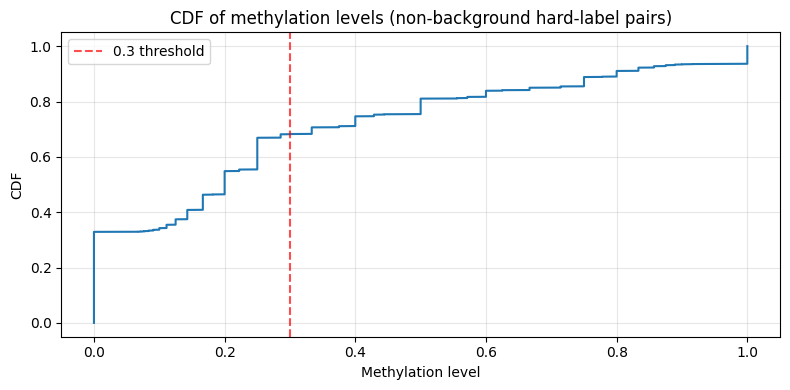

In [16]:
import matplotlib.pyplot as plt

BACKGROUND_LABEL = NUM_CLASSES - 1  # 39

# Filter to (region, sig) pairs whose hard_label is NOT background
non_bg = base_counts[base_counts["hard_label"] != BACKGROUND_LABEL].copy()
print(f"{len(non_bg):,} / {len(base_counts):,} pairs have a non-background hard label")


# Compute methylation level: fraction of CpGs with state=1 in the signature
def methylation_level(sig):
    states = [state for _, state in sig]
    return sum(states) / len(states) if states else np.nan


non_bg["meth_level"] = non_bg["cpg_sig"].apply(methylation_level)

# Ratio below 0.3
n_below = (non_bg["meth_level"] < 0.3).sum()
print(
    f"Methylation level < 0.3: {n_below}/{len(non_bg)} ({100*n_below/len(non_bg):.1f}%)"
)

# Plot CDF
sorted_meth = np.sort(non_bg["meth_level"].dropna().values)
cdf = np.arange(1, len(sorted_meth) + 1) / len(sorted_meth)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sorted_meth, cdf, linewidth=1.5)
ax.axvline(0.3, color="red", linestyle="--", alpha=0.7, label="0.3 threshold")
ax.set_xlabel("Methylation level")
ax.set_ylabel("CDF")
ax.set_title("CDF of methylation levels (non-background hard-label pairs)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
(non_bg["meth_level"] > 0.5).sum() / len(non_bg) * 100

np.float64(18.951783946835086)

## 7. Distribution of argmax vs. DMR cell type across all signatures (not just hypo)

In [18]:
# For all signatures, check how often argmax == dmr_ctype_label
counts_with_dmr["argmax_matches_dmr"] = (
    counts_with_dmr["hard_label"] == counts_with_dmr["dmr_ctype_label"]
)

summary = counts_with_dmr.groupby("is_hypo")["argmax_matches_dmr"].agg(["sum", "count"])
summary["pct"] = 100 * summary["sum"] / summary["count"]
summary.index = summary.index.map({True: "Hypomethylated", False: "Other"})
summary.columns = ["matches", "total", "match_pct"]
summary

,matches,total,match_pct
is_hypo,,,
Other,14237,162783,8.745999
Hypomethylated,6980,7558,92.352474
